<a href="https://colab.research.google.com/github/Rasha27-jcu/data-2000/blob/sp26/homework/060_neural-networks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Homework Assignment: Feed-Forward Neural Networks for Tabular Data

**Objective:** In this assignment, you will build, train, and evaluate a Feed-Forward Neural Network (Multi-Layer Perceptron) to process tabular data. You will use the **MovieLens 100k** dataset to predict user ratings for movies based on various features.

### Instructions
1. Run the provided starter code to load the dataset.
2. Complete the tasks outlined in the markdown cells below.
3. Ensure your code is well-commented and your plots are clearly labeled.
4. Answer any conceptual questions in a separate markdown block.

In [1]:
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

tf.keras.utils.set_random_seed(42)

In [2]:
dataset, ds_info = tfds.load(
    'movielens/100k-ratings',
    split='train',
    with_info=True,
)

# Display some dataset metadata
print(f"\nNumber of examples: {ds_info.splits['train'].num_examples}")
print(f"Dataset features: {list(ds_info.features.keys())}")

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/movielens/100k-ratings/incomplete.HBRPOI_0.1.1/movielens-train.tfrecord*..…

Dataset movielens downloaded and prepared to /root/tensorflow_datasets/movielens/100k-ratings/0.1.1. Subsequent calls will reuse this data.

Number of examples: 100000
Dataset features: ['movie_id', 'movie_title', 'movie_genres', 'user_id', 'user_rating', 'timestamp', 'user_gender', 'bucketized_user_age', 'user_occupation_label', 'user_occupation_text', 'user_zip_code', 'raw_user_age']


## Task 1: Data Exploration
Before building a model, it is crucial to understand your tabular data.

**Your Task:**
1. Extract a batch of records from the dataset (e.g., using `dataset.take(5)`).
2. Print the features and their corresponding values to understand the structure of the data.
3. Identify the target variable (`user_rating`) and continuous/categorical features you might want to use.

In [3]:
records = []
for example in dataset.take(5):
    # Convert each tensor value to a numpy value
    record = {feature_name: feature_value.numpy() for feature_name, feature_value in example.items()}
    records.append(record)

df = pd.DataFrame(records)
df

,bucketized_user_age,movie_genres,movie_id,movie_title,raw_user_age,timestamp,user_gender,user_id,user_occupation_label,user_occupation_text,user_rating,user_zip_code
0,45.0,[7],b'357',"b""One Flew Over the Cuckoo's Nest (1975)""",46.0,879024327,True,b'138',4,b'doctor',4.0,b'53211'
1,25.0,"[4, 14]",b'709',b'Strictly Ballroom (1992)',32.0,875654590,True,b'92',5,b'entertainment',2.0,b'80525'
2,18.0,[4],b'412',"b'Very Brady Sequel, A (1996)'",24.0,882075110,True,b'301',17,b'student',4.0,b'55439'
3,50.0,"[5, 7]",b'56',b'Pulp Fiction (1994)',50.0,883326919,True,b'60',4,b'healthcare',4.0,b'06472'
4,50.0,"[10, 16]",b'895',b'Scream 2 (1997)',55.0,891409199,True,b'197',18,b'technician',3.0,b'75094'


## Task 2: Data Preprocessing


### Step 1: Extract Specific Features
First, we isolate the specific features we want our neural network to learn from. We extract `user_zip_code`, `user_gender`, `raw_user_age`, and `movie_genres` as our inputs, and `user_rating` as our target variable. We cast numerical and boolean fields to `tf.float32` for compatibility with TensorFlow.

In [4]:
def preprocess_data(features):
    inputs = {
        'user_zip_code': features['user_zip_code'],
        'user_gender': tf.cast(features['user_gender'], tf.float32),
        'raw_user_age': tf.cast(features['raw_user_age'], tf.float32),
        'movie_genres': features['movie_genres']
    }
    target = features['user_rating']
    return inputs, target

processed_dataset = dataset.map(preprocess_data)

### Step 2: Build Vocabularies and Normalize Data
Neural networks require numerical inputs, so we cannot pass raw strings or unscaled numbers directly.
- **Categorical Data**: We use a `Hashing` layer to convert high-cardinality string categories (like `user_zip_code`) into a fixed number of integer bins (e.g., 1000 bins). This avoids the need to compute and store a large vocabulary.
- **Multi-Categorical Data**: Since movies can have multiple genres, we use `IntegerLookup` with `multi_hot` encoding to represent genres as a multi-hot array. We can significantly speed up the .adapt() call by batching the dataset before passing it to the method. Processing the data in large batches (e.g., batch(10000)) allows TensorFlow to vectorize the operations and is much more efficient than processing one record at a time. Because the number of genres each movie has can vary (we call these ragged tensors), we will use the `.ragged_batch()` method.
- **Continuous Data**: We use a `Normalization` layer to scale continuous variables like `raw_user_age` so they have a mean of 0 and standard deviation of 1, which helps the network learn faster.

In [5]:
zip_code_hashing = tf.keras.layers.Hashing(num_bins=1000)

In [6]:
# Movie Genres Lookup (Multi-Hot)
genre_lookup = tf.keras.layers.IntegerLookup(output_mode='multi_hot')
genre_lookup.adapt(dataset.map(lambda x: x['movie_genres']).ragged_batch(10000))

In [7]:
# Age Normalization
age_normalization = tf.keras.layers.Normalization(axis=None)
age_normalization.adapt(
    dataset.map(lambda x: tf.cast(x['raw_user_age'], tf.float32)).batch(10000)
)

In [8]:
# Apply the transformations
def encode_features(inputs, target):
    encoded_inputs = {
        'user_zip_code': zip_code_hashing(inputs['user_zip_code']),
        'user_gender': inputs['user_gender'],
        'raw_user_age': age_normalization(inputs['raw_user_age']),
        'movie_genres': genre_lookup(inputs['movie_genres'])
    }
    return encoded_inputs, target

encoded_dataset = processed_dataset.map(encode_features)

### Step 3: Train/Test Split
To properly evaluate our model, we must test it on data it hasn't seen during training. We shuffle the dataset randomly and split it: 80% for training and 20% for testing.

In [9]:
num_examples = ds_info.splits['train'].num_examples
train_size = int(0.8 * num_examples)

encoded_dataset = encoded_dataset.shuffle(10000, seed=42)

train_dataset = encoded_dataset.take(train_size)
test_dataset = encoded_dataset.skip(train_size)

### Step 4: Batching and Prefetching
Finally, we group our data into batches (e.g., 32 records at a time) for more efficient memory usage during training.

We also use `.cache()` to keep the data in memory after the first epoch, and `.prefetch(tf.data.AUTOTUNE)` to allow the CPU to prepare the next batch of data while the GPU/CPU is simultaneously training the model on the current batch.

In [10]:
batch_size = 32

train_dataset = train_dataset.batch(batch_size).cache().prefetch(tf.data.AUTOTUNE)
test_dataset = test_dataset.batch(batch_size).cache().prefetch(tf.data.AUTOTUNE)

print(f"Zip Code Bins: {zip_code_hashing.num_bins}")
print(f"Movie Genres Vocabulary Size: {genre_lookup.vocabulary_size()}")
print("Datasets successfully prepared, batched, and prefetched.")

Zip Code Bins: 1000
Movie Genres Vocabulary Size: 20
Datasets successfully prepared, batched, and prefetched.


## Task 3: Build the Feed-Forward Neural Network


Now you will design the architecture of your neural network for regression.

**Your Task:**
1. Use the Keras Functional API to build a feed-forward neural network.
2. Ensure your input layers correctly handle the shapes of the features you extracted. For categorical features that have been converted to integers (like `user_zip_code` which we hashed into bins), you must use an `Embedding` layer to map these integer indices into dense, continuous vectors. Remember to `Flatten` or pool the embedding output to remove the sequence dimension before concatenating it with your continuous and multi-hot features.
3. Add at least two `Dense` hidden layers with ReLU activation functions. Experiment with the number of neurons.
4. Add a final `Dense` output layer. Since this is a regression task predicting a single continuous value (`user_rating`), how many units should the output layer have, and what should the activation function be?

### Example Usage of Embedding and Flatten Layers


Here is a quick example of how you might process a categorical integer input using the Functional API before concatenating it with other features:

```python
# Define the input (shape is (1,) for a single
# categorical value per record)
categorical_input = tf.keras.Input(
    shape=(1,),
    name='example_cat_feature',
    dtype=tf.int64)

# Apply Embedding, in this case using the
# 1000 bins we created with our ZIP Code hash
# and outputting an embedding dimension of 16
embedding = tf.keras.layers.Embedding(
    input_dim=1000,
    output_dim=16)(categorical_input)
# The output shape here is (batch_size, 1, 16)

# Flatten to remove the extra sequence dimension
flattened_embedding = tf.keras.layers.Flatten()(embedding)
# The output shape is now (batch_size, 16), and is
# ready to be concatenated with the other inputs
```

### Model Code

In [11]:
user_zip_code_input = tf.keras.Input(
    shape=(1,),
    name='user_zip_code',
    dtype=tf.int64)
user_gender_input = tf.keras.Input(
    shape=(1,),
    name='user_gender',
    dtype=tf.float32)
raw_user_age_input = tf.keras.Input(
    shape=(1,),
    name='raw_user_age',
    dtype=tf.float32)

# The shape of movie_genres is the vocabulary size,
# which is a multi-hot vector
movie_genres_input = tf.keras.Input(
    shape=(genre_lookup.vocabulary_size(),),
    name='movie_genres',
    dtype=tf.float32)

# Reduce the categorical user_zip_code to a dense matrix
# using an Embedding layer
embedding_dim = 16
zip_code_embedding = tf.keras.layers.Embedding(
    input_dim=zip_code_hashing.num_bins,
    output_dim=embedding_dim)(user_zip_code_input)

flattened_zip_code = tf.keras.layers.Flatten()(zip_code_embedding)

# Concatenate all features
concatenated_features = tf.keras.layers.concatenate([
    flattened_zip_code,
    user_gender_input,
    raw_user_age_input,
    movie_genres_input
])

# Add Dense hidden layers
x = tf.keras.layers.Dense(64, activation='relu')(concatenated_features)
x = tf.keras.layers.Dense(32, activation='relu')(x)

output_layer = tf.keras.layers.Dense(1, activation='linear', name='user_rating')(x)

# Define the model
model = tf.keras.Model(
    inputs={
        'user_zip_code': user_zip_code_input,
        'user_gender': user_gender_input,
        'raw_user_age': raw_user_age_input,
        'movie_genres': movie_genres_input
    },
    outputs=output_layer
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ user_zip_code       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 1, 16)     │     16,000 │ user_zip_code[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 16)        │          0 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ user_gender         │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ raw_user_age        │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ movie_genres        │ (None, 20)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 38)        │          0 │ flatten[0][0],    │
│ (Concatenate)       │                   │            │ user_gender[0][0… │
│                     │                   │            │ raw_user_age[0][… │
│                     │                   │            │ movie_genres[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      2,496 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │      2,080 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ user_rating (Dense) │ (None, 1)         │         33 │ dense_1[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 20,609 (80.50 KB)

 Trainable params: 20,609 (80.50 KB)

 Non-trainable params: 0 (0.00 B)

The output layer should have 1 unit, because we are predicting a single continuous value the movie rating.

What should the activation function be?
The activation function should be 'linear' (or no activation), because this is a regression task where we need the raw numerical output.

## Task 4: Model Compilation, Training, and Evaluation

**Your Task:**
1. **Compile the model:** Use the Adam optimizer and Mean Squared Error (`mse`) or Mean Absolute Error (`mae`) for the loss function.
2. **Train the model:** Call `model.fit()` on your training dataset for at least 20 epochs. Use the test dataset as validation data.
3. **Plot training curves:** Extract the loss metric from the training history and plot it over the epochs.
4. **Evaluate:** Print out the final Mean Absolute Error (MAE) or Mean Squared Error (MSE) on the test dataset.

In [12]:
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

In [13]:
history = model.fit(
    train_dataset,
    epochs=20,
    validation_data=test_dataset
)

Epoch 1/20
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - loss: 1.3547 - mae: 0.9145 - val_loss: 1.0719 - val_mae: 0.8299
Epoch 2/20
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - loss: 1.0582 - mae: 0.8273 - val_loss: 1.0384 - val_mae: 0.8152
Epoch 3/20
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 1.0250 - mae: 0.8122 - val_loss: 1.0214 - val_mae: 0.8073
Epoch 4/20
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - loss: 1.0027 - mae: 0.8019 - val_loss: 1.0152 - val_mae: 0.8037
Epoch 5/20
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.9862 - mae: 0.7942 - val_loss: 1.0125 - val_mae: 0.8014
Epoch 6/20
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.9731 - mae: 0.7881 - val_loss: 1.0098 - val_mae: 0.7994
Epoch 7/20
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.9622 - mae: 0.7832 - val_loss: 1.0072 - val_mae: 0.7974
Epoch 8/20
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.9530 - mae: 0.7789 - val_loss: 1.0067 - val_mae: 0.7966
Epoch 9/20
2500/2500 ━━━━━━━━━━━━━━━━━━

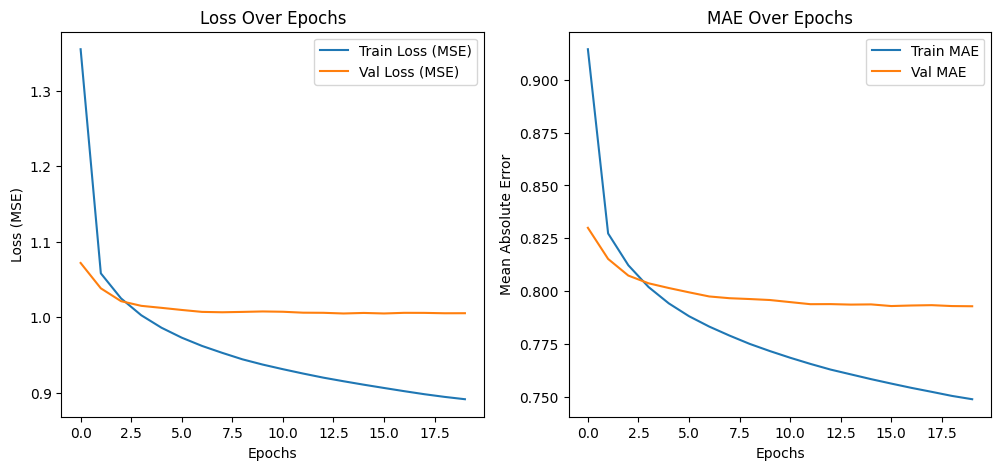

In [14]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss (MSE)')
plt.plot(history.history['val_loss'], label='Val Loss (MSE)')
plt.title('Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Val MAE')
plt.title('MAE Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error')
plt.legend()

plt.show()

In [15]:
results = model.evaluate(test_dataset)
print(f"Final Test MSE: {results[0]}")
print(f"Final Test MAE: {results[1]}")

625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 1.0055 - mae: 0.7928
Final Test MSE: 1.00546133518219
Final Test MAE: 0.7928096652030945
